# **Requirement 1: Single Campaign and Stochastic Environment**

We model the online advertising bidding problem as a Multi-Armed Bandit (MAB).

At each round $t$, an advertiser:
1. Observes an auction opportunity (an impression).
2. Submits a **bid** $b_t$ from a discrete set of bids $\mathcal{B} = \{b^{(1)}, \ldots, b^{(K)}\}$ (arms).
3. Wins the auction if $b_t$ exceeds the **highest competing bid** $c_t$ (drawn i.i.d. from an unknown distribution $F$).
4. If it wins, it pays $c_t$ (first-price) and receives a **value** $v$ (assumed known for a single campaign).
5. The **reward** is: $r_t = (v - c_t) \cdot \mathbf{1}[b_t \geq c_t]$.

The stochastic environment is a distribution over the highest competing bid $c_t$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

---
## Part 1: Build a Stochastic Environment

The environment draws the highest competing bid $c_t \sim F$ i.i.d. at each round.

We use a **Beta distribution** scaled to $[0, 1]$ to model $F$ (it is flexible and bounded).

Each arm $b^{(k)}$ corresponds to a specific bid value. When the agent plays arm $k$ (bids $b^{(k)}$), the expected reward is:
$$\mu_k = \mathbb{E}_{c \sim F}[(v - c) \cdot \mathbf{1}[b^{(k)} \geq c]]$$

Since $c_t$ is i.i.d., **the reward for each arm is i.i.d. across rounds** — this is exactly a stochastic MAB.

In [2]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta, norm

In [3]:
# Ensure project root is in path for imports
sys.path.append(os.path.abspath(os.path.join('..')))
from src.environments import SingleCampaignEnvironment


We can design different environments by changing the distribution function of the highest competing bids. 

In [4]:
def uniform_generator(size):
    return np.random.uniform(0.0, 1.0, size=size)

def beta_generator(size, a=2, b = 5):
    # a=2, b=5 creates a right-skewed profile (most competing bids are low)
    return np.random.beta(a, b, size=size)

def clipped_gaussian_generator(size):
    # Mean=0.4, Std=0.15; Clipped strictly to [0, 1] to respect auction bounds
    raw_samples = np.random.normal(loc=0.4, scale=0.15, size=size)
    return np.clip(raw_samples, 0.0, 1.0)


Let's see what these distribution look like for the highest competing bids : 

In [5]:
T = 1000
value = 1.0

env_uniform = SingleCampaignEnvironment(value=value, T=T, distribution_func=uniform_generator)
env_beta    = SingleCampaignEnvironment(value=value, T=T, distribution_func=beta_generator)
env_gaussian= SingleCampaignEnvironment(value=value, T=T, distribution_func=clipped_gaussian_generator)

# to extract the generated bids from the environment  
m_unif = env_uniform.get_m_sequence().flatten()
m_beta = env_beta.get_m_sequence().flatten()
m_gaus = env_gaussian.get_m_sequence().flatten()

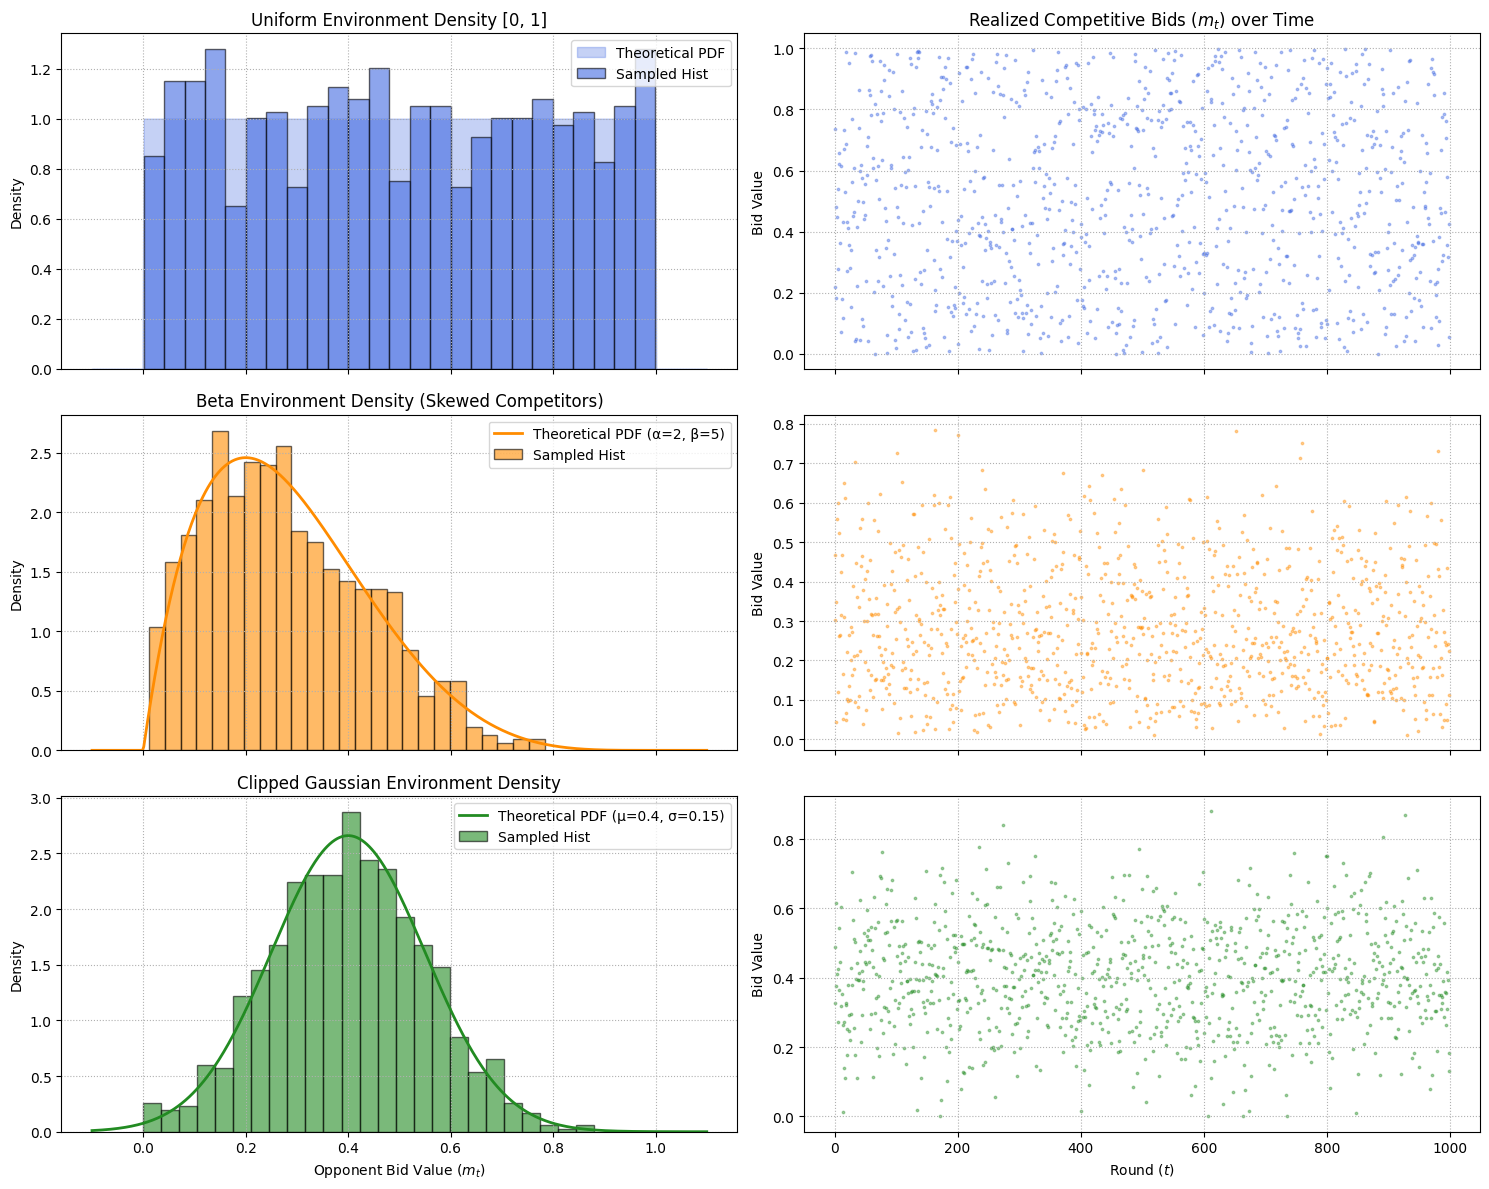

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(15, 12), sharex='col')

# --- ROW 1: UNIFORM ENVIRONMENT ---
# Theoretical Density
x_axis = np.linspace(-0.1, 1.1, 500)
axes[0, 0].fill_between(x_axis, (x_axis >= 0) & (x_axis <= 1), alpha=0.3, color='royalblue', label='Theoretical PDF')
axes[0, 0].hist(m_unif, bins=25, density=True, alpha=0.6, color='royalblue', edgecolor='black', label='Sampled Hist')
axes[0, 0].set_title('Uniform Environment Density [0, 1]')
axes[0, 0].set_ylabel('Density')
axes[0, 0].legend()
axes[0, 0].grid(True, linestyle=':')

# Realized Sequence over Time
axes[0, 1].scatter(range(T), m_unif, s=3, alpha=0.4, color='royalblue')
axes[0, 1].set_title('Realized Competitive Bids ($m_t$) over Time')
axes[0, 1].set_ylabel('Bid Value')
axes[0, 1].grid(True, linestyle=':')

# --- ROW 2: BETA ENVIRONMENT ---
# Theoretical Density
axes[1, 0].plot(x_axis, beta.pdf(x_axis, 2, 5), color='darkorange', lw=2, label='Theoretical PDF (α=2, β=5)')
axes[1, 0].hist(m_beta, bins=25, density=True, alpha=0.6, color='darkorange', edgecolor='black', label='Sampled Hist')
axes[1, 0].set_title('Beta Environment Density (Skewed Competitors)')
axes[1, 0].set_ylabel('Density')
axes[1, 0].legend()
axes[1, 0].grid(True, linestyle=':')

# Realized Sequence over Time
axes[1, 1].scatter(range(T), m_beta, s=3, alpha=0.4, color='darkorange')
axes[1, 1].set_ylabel('Bid Value')
axes[1, 1].grid(True, linestyle=':')

# --- ROW 3: CLIPPED GAUSSIAN ENVIRONMENT ---
# Theoretical Density (Approximated via matching parameters)
axes[2, 0].plot(x_axis, norm.pdf(x_axis, 0.4, 0.15), color='forestgreen', lw=2, label='Theoretical PDF (μ=0.4, σ=0.15)')
axes[2, 0].hist(m_gaus, bins=25, density=True, alpha=0.6, color='forestgreen', edgecolor='black', label='Sampled Hist')
axes[2, 0].set_title('Clipped Gaussian Environment Density')
axes[2, 0].set_xlabel('Opponent Bid Value ($m_t$)')
axes[2, 0].set_ylabel('Density')
axes[2, 0].legend()
axes[2, 0].grid(True, linestyle=':')

# Realized Sequence over Time
axes[2, 1].scatter(range(T), m_gaus, s=3, alpha=0.4, color='forestgreen')
axes[2, 1].set_xlabel('Round ($t$)')
axes[2, 1].set_ylabel('Bid Value')
axes[2, 1].grid(True, linestyle=':')

plt.tight_layout()
plt.show()

---
## Part 2: Algorithm 1 — UCB1 Ignoring the Budget Constraint

We treat the bidding problem as a standard MAB: at each round pick the arm with the highest **Upper Confidence Bound**:

$$\text{UCB}_k(t) = \hat{\mu}_k(t) + \sqrt{\frac{2 \ln T}{N_k(t)}}$$

where $\hat{\mu}_k(t)$ is the empirical mean reward of arm $k$ after $N_k(t)$ pulls.

This completely **ignores the budget** — the agent may overspend.

In [7]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# Route module lookups to the src directory
sys.path.append(os.path.abspath(os.path.join('..')))
from src.environments import SingleCampaignEnvironment
from src.learner import SingleCampaignUCB1Learner

def uniform_generator(size):
    return np.random.uniform(0.0, 1.0, size=size)


Testing the environment on a simple run : 

Let's try out this simple agent for MABs 

## For a uniform distribution : 

In [8]:
T = 10000
K = 11
value = 1.0
bid_space = np.linspace(0.0, 1.0, K)

# 2. Initialization
np.random.seed(42)
env = SingleCampaignEnvironment(value=value, T=T, distribution_func=uniform_generator)
agent = SingleCampaignUCB1Learner(value=value, bid_space=bid_space)

# 3. Tracking Arrays
history_rewards_agent = np.zeros(T)
history_bids_agent = np.zeros(T)
snapshot_t2_means = np.zeros(K)
snapshot_t2_pulls = np.zeros(K)

# 4. Execution Loop
for t in range(T):
    arm_idx = agent.pull_arm()
    b_t = bid_space[arm_idx]
    
    won, utility, cost = env.resolve_auction(b_t)
    agent.update(won, utility, cost)
    
    history_rewards_agent[t] = utility
    history_bids_agent[t] = b_t
    
    if t == (T // 4) - 1:
        snapshot_t2_means = np.copy(agent.average_rewards)
        snapshot_t2_pulls = np.copy(agent.pulls)


In [9]:

# 5. Compute Expected Baselines
# -- Discrete OPT --
sampled_m = uniform_generator(100000)
win_probabilities = np.mean(sampled_m[:, None] <= bid_space, axis=0)
expected_rewards = (value - bid_space) * win_probabilities

OPT_discrete = np.max(expected_rewards)
best_discrete_bid = bid_space[np.argmax(expected_rewards)]

# -- Continuous OPT (Analytical for Uniform U(0,1)) --
OPT_continuous = 0.25
best_continuous_bid = 0.50

In [10]:
# 6. Regret Mathematics & UCB State Calculations
time_steps = np.arange(1, T + 1)
expected_cum_disc = time_steps * OPT_discrete
expected_cum_cont = time_steps * OPT_continuous
cum_rewards_agent = np.cumsum(history_rewards_agent)

regret_vs_disc = expected_cum_disc - cum_rewards_agent
regret_vs_cont = expected_cum_cont - cum_rewards_agent

safe_pulls_t2 = np.maximum(snapshot_t2_pulls, 1.0)
exploration_radius_t2 = np.sqrt(2 * np.log(T / 2) / safe_pulls_t2)
ucb_t2 = snapshot_t2_means + exploration_radius_t2

safe_pulls_T = np.maximum(agent.pulls, 1.0)
exploration_radius_T = np.sqrt(2 * np.log(T) / safe_pulls_T)
ucb_T = agent.average_rewards + exploration_radius_T

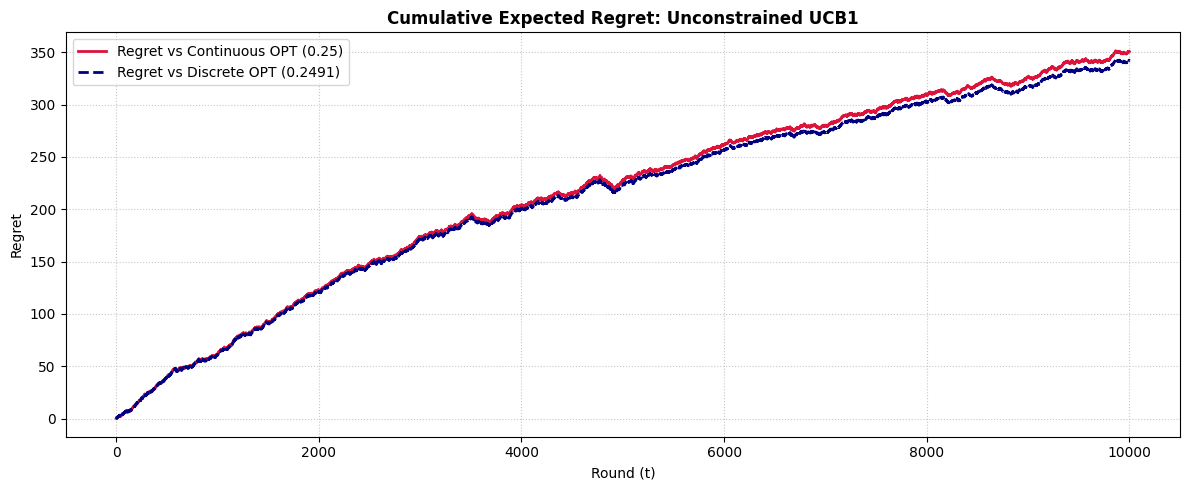

Discrete OPT per round  : 0.2491 (Bid: 0.50)
Continuous OPT per round: 0.2500 (Bid: 0.50)
Final Regret vs Discrete: 342.25


In [11]:

# 7. Visualization
plt.figure(figsize=(12, 5))
plt.plot(time_steps, regret_vs_cont, color='crimson', lw=2, label=f'Regret vs Continuous OPT ({OPT_continuous:.2f})')
plt.plot(time_steps, regret_vs_disc, color='navy', linestyle='--', lw=2, label=f'Regret vs Discrete OPT ({OPT_discrete:.4f})')
plt.title("Cumulative Expected Regret: Unconstrained UCB1", fontweight='bold')
plt.xlabel("Round (t)")
plt.ylabel("Regret")
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# 8. Terminal Diagnostics
print(f"Discrete OPT per round  : {OPT_discrete:.4f} (Bid: {best_discrete_bid:.2f})")
print(f"Continuous OPT per round: {OPT_continuous:.4f} (Bid: {best_continuous_bid:.2f})")
print(f"Final Regret vs Discrete: {regret_vs_disc[-1]:.2f}")

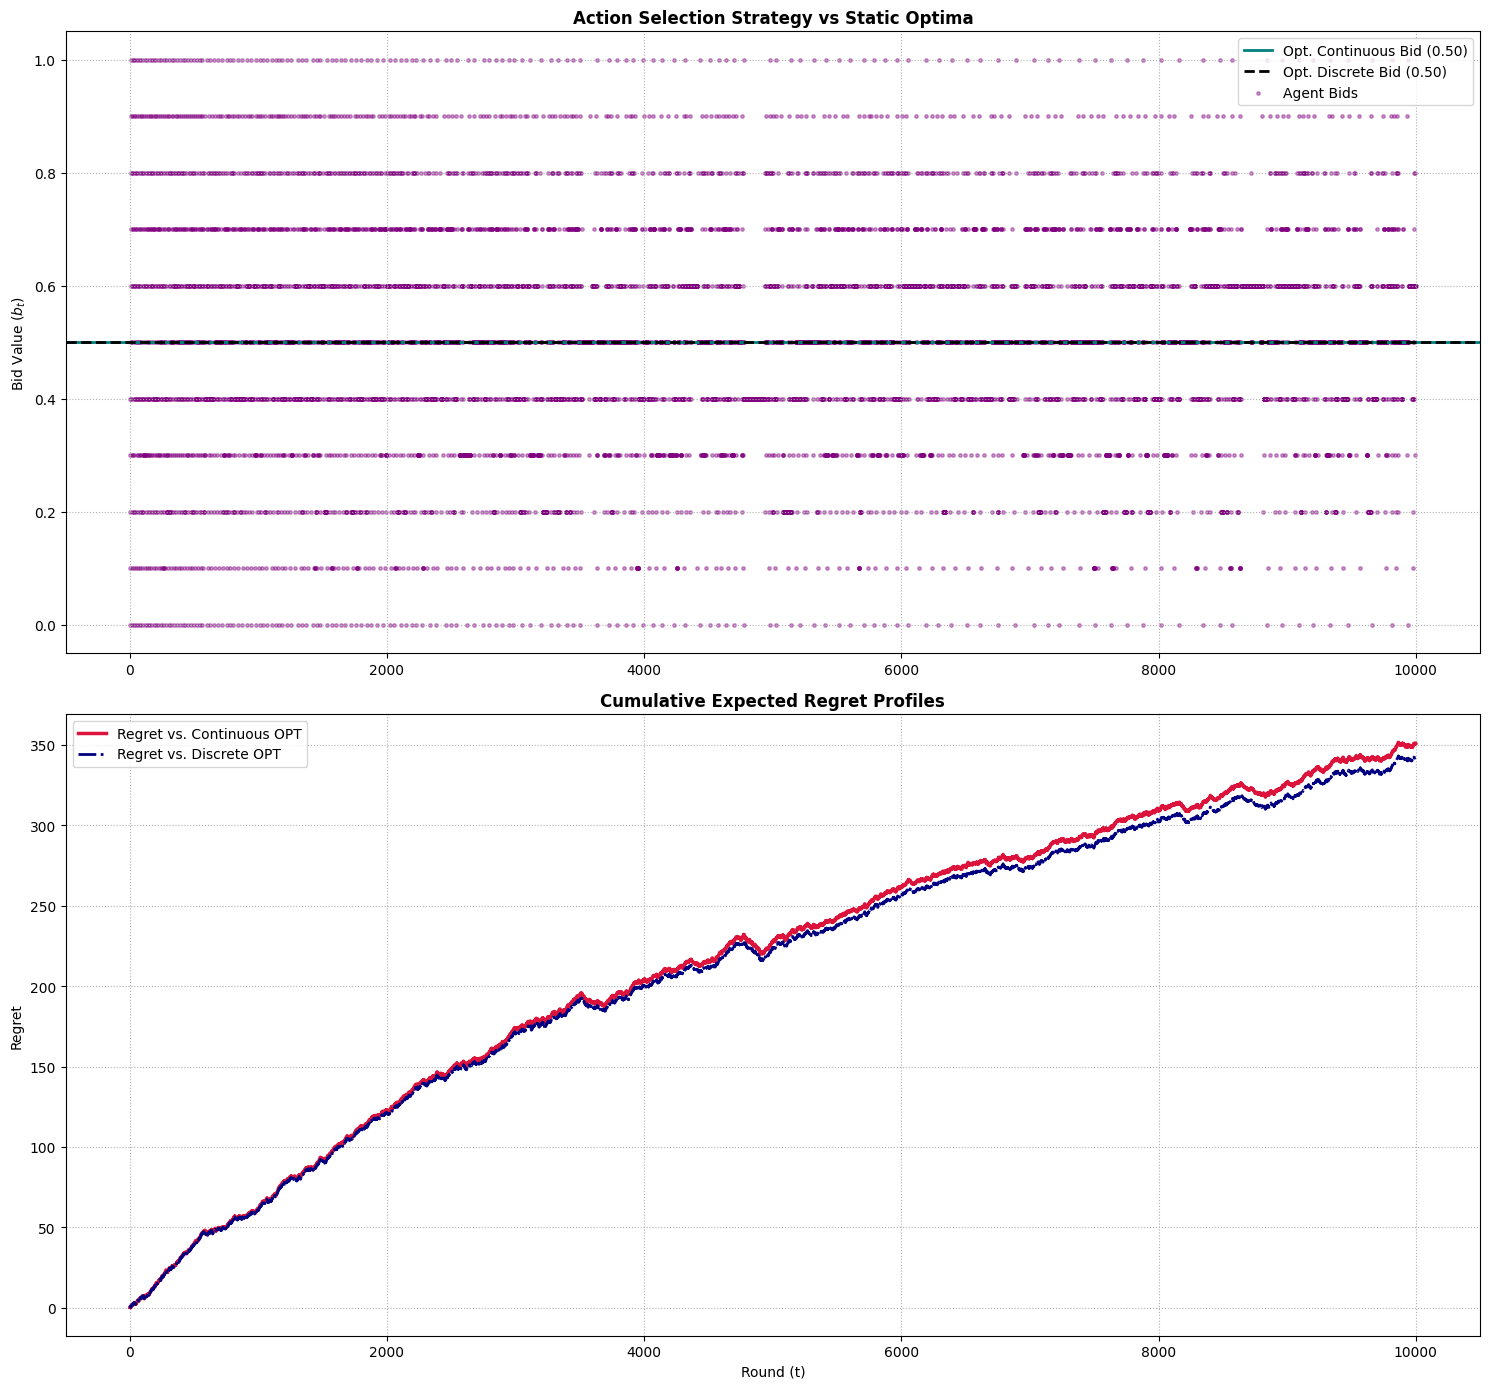

In [12]:
plt.figure(figsize=(15, 14))

# --- PLOT 1: Action Selection ---
plt.subplot(2, 1, 1)
# Static optimal bids are horizontal lines, not scattered points
plt.axhline(y=best_continuous_bid, color='teal', linestyle='-', lw=2, label=f'Opt. Continuous Bid ({best_continuous_bid:.2f})')
plt.axhline(y=best_discrete_bid, color='black', linestyle='--', lw=2, label=f'Opt. Discrete Bid ({best_discrete_bid:.2f})')
plt.scatter(time_steps, history_bids_agent, s=6, color='purple', alpha=0.4, label='Agent Bids')
plt.title('Action Selection Strategy vs Static Optima', fontweight='bold')
plt.ylabel('Bid Value ($b_t$)')
plt.grid(True, linestyle=':')
plt.legend(loc='upper right')

# --- PLOT 2: Expected Regret ---
plt.subplot(2, 1, 2)
plt.plot(time_steps, regret_vs_cont, color='crimson', lw=2.5, label='Regret vs. Continuous OPT')
plt.plot(time_steps, regret_vs_disc, color='navy', lw=2, linestyle='-.', label='Regret vs. Discrete OPT')
plt.title('Cumulative Expected Regret Profiles', fontweight='bold')
plt.xlabel('Round (t)')
plt.ylabel('Regret')
plt.grid(True, linestyle=':')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

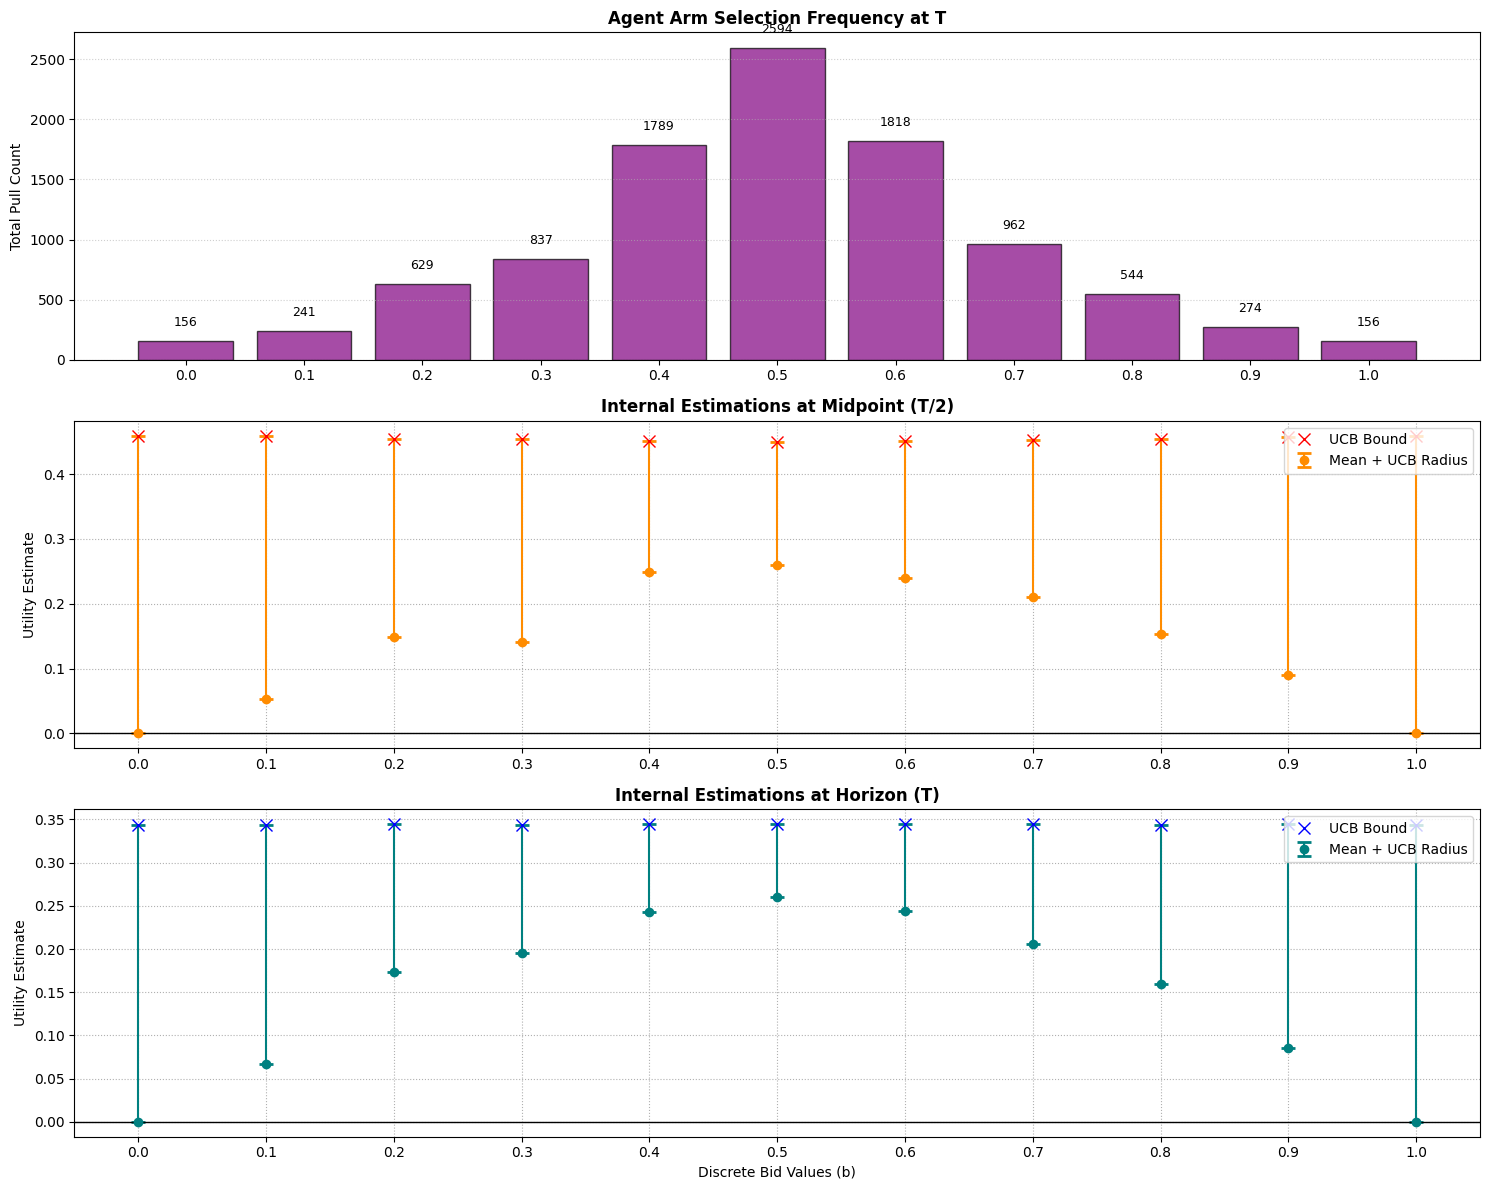

In [13]:
plt.figure(figsize=(15, 12))
arm_indices = np.arange(K)
bid_labels = [f"{b:.1f}" for b in bid_space]
# --- PLOT 1: Arm Selection Frequency ---
plt.subplot(3, 1, 1)
# FIXED: agent.N_pulls -> agent.pulls
bars = plt.bar(arm_indices, agent.pulls, color='purple', edgecolor='black', alpha=0.7)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + (T*0.01), f"{int(yval)}", ha='center', va='bottom', fontsize=9)
plt.title('Agent Arm Selection Frequency at T', fontweight='bold')
plt.ylabel('Total Pull Count')
plt.xticks(arm_indices, bid_labels)
plt.grid(axis='y', linestyle=':', alpha=0.6)

# --- PLOT 2: Internal Estimations at Midpoint (T/2) ---
plt.subplot(3, 1, 2)
plt.errorbar(arm_indices, snapshot_t2_means, yerr=[np.zeros(K), exploration_radius_t2], 
             fmt='o', color='darkorange', capsize=5, capthick=2, label='Mean + UCB Radius')
plt.plot(arm_indices, ucb_t2, 'x', color='red', markersize=8, label='UCB Bound')
plt.axhline(y=0, color='black', linewidth=1)
plt.title('Internal Estimations at Midpoint (T/2)', fontweight='bold')
plt.ylabel('Utility Estimate')
plt.xticks(arm_indices, bid_labels)
plt.grid(True, linestyle=':')
plt.legend(loc='upper right')

# --- PLOT 3: Internal Estimations at Horizon (T) ---
plt.subplot(3, 1, 3)
plt.errorbar(arm_indices, agent.average_rewards, yerr=[np.zeros(K), exploration_radius_T], 
             fmt='o', color='teal', capsize=5, capthick=2, label='Mean + UCB Radius')
plt.plot(arm_indices, ucb_T, 'x', color='blue', markersize=8, label='UCB Bound')
plt.axhline(y=0, color='black', linewidth=1)
plt.title('Internal Estimations at Horizon (T)', fontweight='bold')
plt.xlabel('Discrete Bid Values (b)')
plt.ylabel('Utility Estimate')
plt.xticks(arm_indices, bid_labels)
plt.grid(True, linestyle=':')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

## For other distributions : 

In [14]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

# Route module lookups to the src directory
sys.path.append(os.path.abspath(os.path.join('..')))
from src.environments import SingleCampaignEnvironment
from src.learner import SingleCampaignUCB1Learner

Executing Monte Carlo for Uniform...
Executing Monte Carlo for Beta(2,5)...
Executing Monte Carlo for Gaussian(0.4, 0.15)...


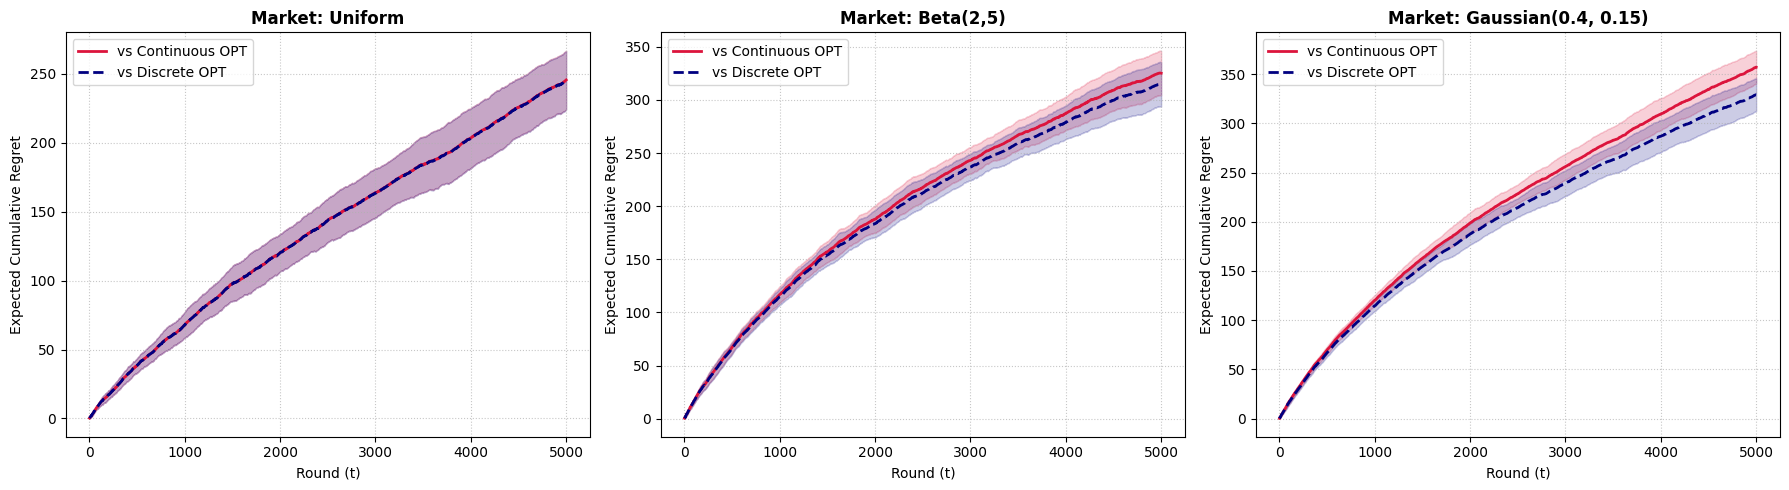

In [15]:


# --- 1. Global Configuration ---
T = 5000
K = 11
N_SIMULATIONS = 20  # Minimum required for statistical significance
value = 1.0
bid_space = np.linspace(0.0, 1.0, K)

# --- 2. Market Generators ---
def uniform_generator(size):
    return np.random.uniform(0.0, 1.0, size=size)

def beta_generator(size, a=2, b=5):
    return np.random.beta(a, b, size=size)

def clipped_gaussian_generator(size):
    raw_samples = np.random.normal(loc=0.4, scale=0.15, size=size)
    return np.clip(raw_samples, 0.0, 1.0)

environments = {
    'Uniform': uniform_generator,
    'Beta(2,5)': beta_generator,
    'Gaussian(0.4, 0.15)': clipped_gaussian_generator
}

# --- 3. Fluid Baseline Solvers ---
def compute_baselines(generator_func, bid_space, value, sample_size=500000):
    """Numerically computes Discrete and Continuous OPT via Monte Carlo integration."""
    samples = generator_func(sample_size)
    
    # Discrete OPT
    win_probs = np.mean(samples[:, None] <= bid_space, axis=0)
    expected_rewards_disc = (value - bid_space) * win_probs
    OPT_discrete = np.max(expected_rewards_disc)
    
    # Continuous OPT (Numerical Optimization)
    def neg_expected_reward(b):
        if b < 0.0 or b > 1.0: return 0.0
        prob_win = np.mean(samples <= b)
        return -((value - b) * prob_win)
        
    res = minimize_scalar(neg_expected_reward, bounds=(0.0, 1.0), method='bounded')
    OPT_continuous = -res.fun
    
    return OPT_discrete, OPT_continuous

# --- 4. Execution Engine ---
results = {}

for env_name, gen_func in environments.items():
    print(f"Executing Monte Carlo for {env_name}...")
    OPT_disc, OPT_cont = compute_baselines(gen_func, bid_space, value)
    
    # Matrices to hold multiple trajectories
    regret_matrix_disc = np.zeros((N_SIMULATIONS, T))
    regret_matrix_cont = np.zeros((N_SIMULATIONS, T))
    
    for sim in range(N_SIMULATIONS):
        env = SingleCampaignEnvironment(value=value, T=T, distribution_func=gen_func)
        agent = SingleCampaignUCB1Learner(value=value, bid_space=bid_space)
        
        trajectory_rewards = np.zeros(T)
        
        for t in range(T):
            arm_idx = agent.pull_arm()
            b_t = bid_space[arm_idx]
            won, utility, cost = env.resolve_auction(b_t)
            agent.update(won, utility, cost)
            trajectory_rewards[t] = utility
            
        cum_rewards = np.cumsum(trajectory_rewards)
        time_steps = np.arange(1, T + 1)
        
        regret_matrix_disc[sim, :] = (time_steps * OPT_disc) - cum_rewards
        regret_matrix_cont[sim, :] = (time_steps * OPT_cont) - cum_rewards

    results[env_name] = {
        'mean_regret_disc': np.mean(regret_matrix_disc, axis=0),
        'std_regret_disc': np.std(regret_matrix_disc, axis=0),
        'mean_regret_cont': np.mean(regret_matrix_cont, axis=0),
        'std_regret_cont': np.std(regret_matrix_cont, axis=0)
    }

# --- 5. Visualization ---
time_steps = np.arange(1, T + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (env_name, data) in enumerate(results.items()):
    ax = axes[idx]
    
    # Continuous Regret
    ax.plot(time_steps, data['mean_regret_cont'], color='crimson', lw=2, label='vs Continuous OPT')
    ax.fill_between(time_steps, 
                    data['mean_regret_cont'] - data['std_regret_cont'], 
                    data['mean_regret_cont'] + data['std_regret_cont'], 
                    color='crimson', alpha=0.2)
    
    # Discrete Regret
    ax.plot(time_steps, data['mean_regret_disc'], color='navy', linestyle='--', lw=2, label='vs Discrete OPT')
    ax.fill_between(time_steps, 
                    data['mean_regret_disc'] - data['std_regret_disc'], 
                    data['mean_regret_disc'] + data['std_regret_disc'], 
                    color='navy', alpha=0.2)

    ax.set_title(f'Market: {env_name}', fontweight='bold')
    ax.set_xlabel('Round (t)')
    ax.set_ylabel('Expected Cumulative Regret')
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

### Remark
seems to achieve sublinear regret. 

We can try a variant of the UCB-bidding algorithm : 

Computing theoretical baselines via Monte Carlo integration...
OPT_discrete:   0.2501
OPT_continuous: 0.2501

Executing paired simulation 0/5...


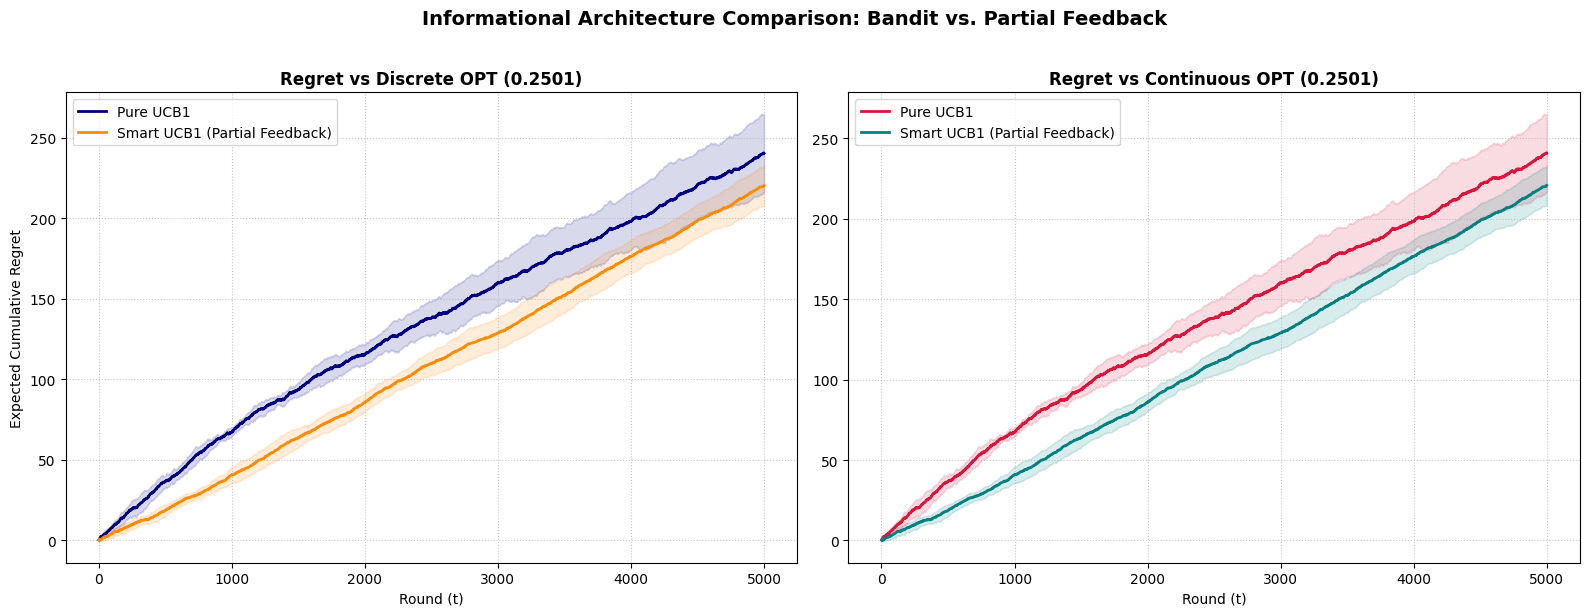

In [16]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

# Route module lookups to the src directory
sys.path.append(os.path.abspath(os.path.join('..')))
from src.environments import SingleCampaignEnvironment
from src.learners import SingleCampaignUCB1Learner, SmartUCB1Agent

# 1. Configuration
T = 5000
K = 11
N_SIMULATIONS = 5
value = 1.0
bid_space = np.linspace(0.0, 1.0, K)

def target_generator(size):
    return np.random.uniform(0.0, 1.0, size=size)

# 2. Compute Fluid Baselines
print("Computing theoretical baselines via Monte Carlo integration...")
samples = target_generator(500000)
win_probs = np.mean(samples[:, None] <= bid_space, axis=0)
expected_rewards_disc = (value - bid_space) * win_probs
OPT_disc = np.max(expected_rewards_disc)

def neg_expected_reward(b):
    if b < 0.0 or b > 1.0: return 0.0
    return -((value - b) * np.mean(samples <= b))

OPT_cont = -minimize_scalar(neg_expected_reward, bounds=(0.0, 1.0), method='bounded').fun

print(f"OPT_discrete:   {OPT_disc:.4f}")
print(f"OPT_continuous: {OPT_cont:.4f}\n")

# 3. Execution Engine
regret_disc_pure = np.zeros((N_SIMULATIONS, T))
regret_cont_pure = np.zeros((N_SIMULATIONS, T))
regret_disc_smart = np.zeros((N_SIMULATIONS, T))
regret_cont_smart = np.zeros((N_SIMULATIONS, T))

for sim in range(N_SIMULATIONS):
    if sim % 5 == 0:
        print(f"Executing paired simulation {sim}/{N_SIMULATIONS}...")
        
    # Instantiate Environments and Agents
    env_pure = SingleCampaignEnvironment(value=value, T=T, distribution_func=target_generator)
    env_smart = SingleCampaignEnvironment(value=value, T=T, distribution_func=target_generator)
    
    agent_pure = SingleCampaignUCB1Learner(value=value, bid_space=bid_space)
    agent_smart = SmartUCB1Agent(value=value, bid_space=bid_space)
    
    traj_pure = np.zeros(T)
    traj_smart = np.zeros(T)
    
    for t in range(T):
        # Pure Agent Execution
        arm_pure = agent_pure.pull_arm()
        b_pure = bid_space[arm_pure]
        won_p, util_p, cost_p = env_pure.resolve_auction(b_pure)
        agent_pure.update(won_p, util_p, cost_p)
        traj_pure[t] = util_p
        
        # Smart Agent Execution
        arm_smart = agent_smart.pull_arm()
        b_smart = bid_space[arm_smart]
        won_s, util_s, cost_s = env_smart.resolve_auction(b_smart)
        agent_smart.update(won_s, util_s, cost_s)
        traj_smart[t] = util_s
        
    # Calculate Cumulative Regret
    time_steps = np.arange(1, T + 1)
    
    regret_disc_pure[sim, :] = (time_steps * OPT_disc) - np.cumsum(traj_pure)
    regret_cont_pure[sim, :] = (time_steps * OPT_cont) - np.cumsum(traj_pure)
    
    regret_disc_smart[sim, :] = (time_steps * OPT_disc) - np.cumsum(traj_smart)
    regret_cont_smart[sim, :] = (time_steps * OPT_cont) - np.cumsum(traj_smart)

# 4. Statistical Aggregation
mean_disc_pure, std_disc_pure = np.mean(regret_disc_pure, axis=0), np.std(regret_disc_pure, axis=0)
mean_cont_pure, std_cont_pure = np.mean(regret_cont_pure, axis=0), np.std(regret_cont_pure, axis=0)

mean_disc_smart, std_disc_smart = np.mean(regret_disc_smart, axis=0), np.std(regret_disc_smart, axis=0)
mean_cont_smart, std_cont_smart = np.mean(regret_cont_smart, axis=0), np.std(regret_cont_smart, axis=0)

# 5. Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Regret vs Discrete OPT
axes[0].plot(time_steps, mean_disc_pure, color='navy', lw=2, label='Pure UCB1')
axes[0].fill_between(time_steps, mean_disc_pure - std_disc_pure, mean_disc_pure + std_disc_pure, color='navy', alpha=0.15)
axes[0].plot(time_steps, mean_disc_smart, color='darkorange', lw=2, label='Smart UCB1 (Partial Feedback)')
axes[0].fill_between(time_steps, mean_disc_smart - std_disc_smart, mean_disc_smart + std_disc_smart, color='darkorange', alpha=0.15)
axes[0].set_title(f'Regret vs Discrete OPT ({OPT_disc:.4f})', fontweight='bold')
axes[0].set_xlabel('Round (t)')
axes[0].set_ylabel('Expected Cumulative Regret')
axes[0].grid(True, linestyle=':', alpha=0.7)
axes[0].legend(loc='upper left')

# Plot 2: Regret vs Continuous OPT
axes[1].plot(time_steps, mean_cont_pure, color='crimson', lw=2, label='Pure UCB1')
axes[1].fill_between(time_steps, mean_cont_pure - std_cont_pure, mean_cont_pure + std_cont_pure, color='crimson', alpha=0.15)
axes[1].plot(time_steps, mean_cont_smart, color='teal', lw=2, label='Smart UCB1 (Partial Feedback)')
axes[1].fill_between(time_steps, mean_cont_smart - std_cont_smart, mean_cont_smart + std_cont_smart, color='teal', alpha=0.15)
axes[1].set_title(f'Regret vs Continuous OPT ({OPT_cont:.4f})', fontweight='bold')
axes[1].set_xlabel('Round (t)')
axes[1].grid(True, linestyle=':', alpha=0.7)
axes[1].legend(loc='upper left')

plt.suptitle('Informational Architecture Comparison: Bandit vs. Partial Feedback', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# UCB-bidding Algo 

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from scipy.optimize import linprog

import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

# Route module lookups to the src directory
sys.path.append(os.path.abspath(os.path.join('..')))
from src.environments import SingleCampaignEnvironment
from src.learners import SingleCampaignBaseLearner, SingleCampaignUCB1Learner, SmartUCB1Agent, BudgetConstrainedUCBAgent, HeuristicBudgetUCBAgent

import numpy as np
from scipy import optimize

In [18]:
from scipy import optimize

## Without Budget Constraint : 

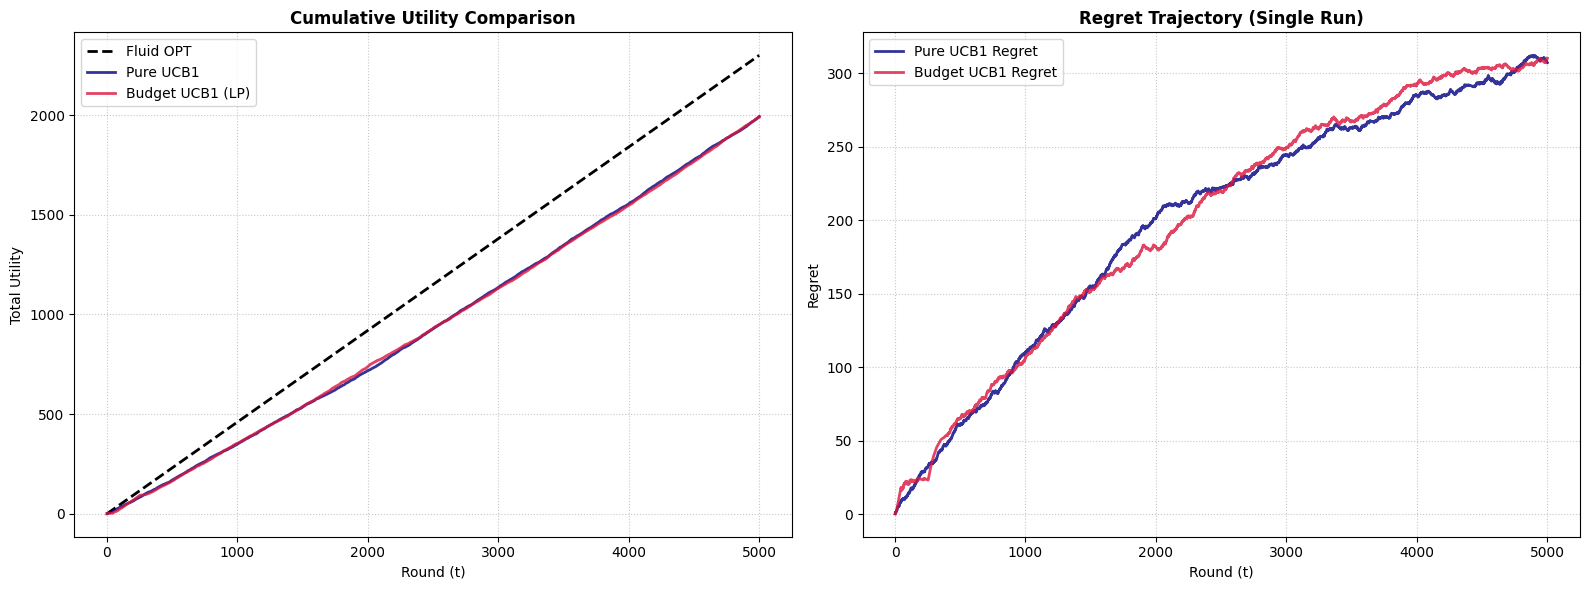

In [19]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from scipy.optimize import linprog

# sys.path.append(os.path.abspath(os.path.join('..')))
# from src.environments import SingleCampaignEnvironment
# from src.learner import SingleCampaignUCB1Learner, BudgetConstrainedUCBAgent

# 1. System Configuration
T = 5000
K = 11
value = 1.0
B = float(T)  # Non-binding budget constraint
rho = B / T
bid_space = np.linspace(0.0, 1.0, K)

alpha_param = 2
beta_param = 5

def beta_generator(size):
    return np.random.beta(alpha_param, beta_param, size=size)

# 2. Expected Fluid Baseline (OPT)
win_probabilities = beta.cdf(bid_space, a=alpha_param, b=beta_param)
expected_rewards = (value - bid_space) * win_probabilities
expected_costs = bid_space * win_probabilities

c_obj_base = -expected_rewards
A_ub_base = expected_costs.reshape(1, -1)
b_ub_base = np.array([rho])
A_eq_base = np.ones((1, K))
b_eq_base = np.array([1.0])
bounds_base = [(0, 1) for _ in range(K)]

res_base = linprog(c_obj_base, A_ub=A_ub_base, b_ub=b_ub_base, A_eq=A_eq_base, b_eq=b_eq_base, bounds=bounds_base, method='highs')
gamma_opt = np.clip(res_base.x, 0, 1)
gamma_opt /= np.sum(gamma_opt)

OPT = np.sum(gamma_opt * expected_rewards)

# 3. Initialization
np.random.seed(42)
env_base = SingleCampaignEnvironment(value=value, T=T, distribution_func=beta_generator)
env_budget = SingleCampaignEnvironment(value=value, T=T, distribution_func=beta_generator)

agent_base = SingleCampaignUCB1Learner(value=value, bid_space=bid_space)
agent_budget = BudgetConstrainedUCBAgent(value=value, bid_space=bid_space, B=B, T=T)

rewards_base = np.zeros(T)
rewards_budget = np.zeros(T)
costs_budget = np.zeros(T)

# 4. Execution Loop (Strictly T iterations)
for t in range(T):
    # Pure UCB Execution
    arm_base = agent_base.pull_arm()
    b_base = bid_space[arm_base]
    won_base, util_base, cost_base = env_base.resolve_auction(b_base)
    agent_base.update(won_base, util_base, cost_base)
    rewards_base[t] = util_base
    
    # Budget UCB Execution
    arm_budget = agent_budget.pull_arm()
    b_budget = bid_space[arm_budget]
    won_budg, util_budg, cost_budg = env_budget.resolve_auction(b_budget)
    agent_budget.update(won_budg, util_budg, cost_budg)
    rewards_budget[t] = util_budg
    costs_budget[t] = cost_budg

# 5. Metrics & Regret
time_steps = np.arange(1, T + 1)
expected_cumulative_baseline = time_steps * OPT

cum_rewards_base = np.cumsum(rewards_base)
cum_rewards_budget = np.cumsum(rewards_budget)

regret_base = expected_cumulative_baseline - cum_rewards_base
regret_budget = expected_cumulative_baseline - cum_rewards_budget

# 6. Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(time_steps, expected_cumulative_baseline, color='black', lw=2, linestyle='--', label=r'Fluid OPT')
axes[0].plot(time_steps, cum_rewards_base, color='navy', lw=2, alpha=0.8, label='Pure UCB1')
axes[0].plot(time_steps, cum_rewards_budget, color='crimson', lw=2, alpha=0.8, label='Budget UCB1 (LP)')
axes[0].set_title('Cumulative Utility Comparison', fontweight='bold')
axes[0].set_xlabel('Round (t)')
axes[0].set_ylabel('Total Utility')
axes[0].grid(True, linestyle=':', alpha=0.7)
axes[0].legend()

axes[1].plot(time_steps, regret_base, color='navy', lw=2, alpha=0.8, label='Pure UCB1 Regret')
axes[1].plot(time_steps, regret_budget, color='crimson', lw=2, alpha=0.8, label='Budget UCB1 Regret')
axes[1].set_title('Regret Trajectory (Single Run)', fontweight='bold')
axes[1].set_xlabel('Round (t)')
axes[1].set_ylabel('Regret')
axes[1].grid(True, linestyle=':', alpha=0.7)
axes[1].legend()

plt.tight_layout()
plt.show()

Executing Monte Carlo Suite: N=30, T=5000, B=5000.0
Running simulation 0/30...
Running simulation 5/30...
Running simulation 10/30...
Running simulation 15/30...
Running simulation 20/30...
Running simulation 25/30...


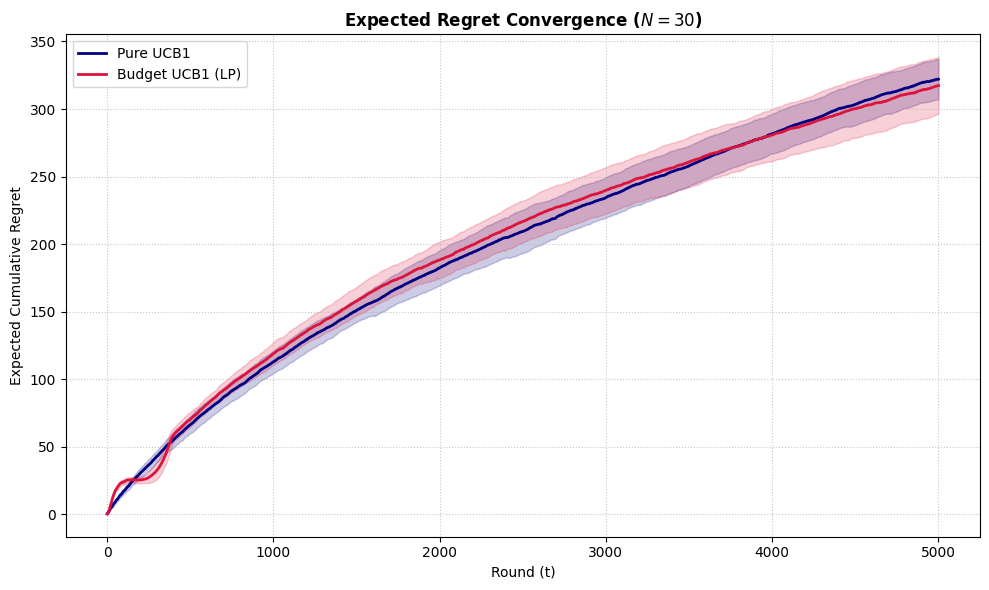

In [4]:
# 1. Statistical Configuration
N_SIMULATIONS = 30

regret_matrix_base = np.zeros((N_SIMULATIONS, T))
regret_matrix_budget = np.zeros((N_SIMULATIONS, T))

print(f"Executing Monte Carlo Suite: N={N_SIMULATIONS}, T={T}, B={B}")

for sim in range(N_SIMULATIONS):
    if sim % 5 == 0:
        print(f"Running simulation {sim}/{N_SIMULATIONS}...")
        
    env_b = SingleCampaignEnvironment(value=value, T=T, distribution_func=beta_generator)
    env_c = SingleCampaignEnvironment(value=value, T=T, distribution_func=beta_generator)
    
    ag_base = SingleCampaignUCB1Learner(value=value, bid_space=bid_space)
    ag_budg = BudgetConstrainedUCBAgent(value=value, bid_space=bid_space, B=B, T=T)
    
    traj_base = np.zeros(T)
    traj_budg = np.zeros(T)
    
    for t in range(T):
        arm_b = ag_base.pull_arm()
        won_b, util_b, cost_b = env_b.resolve_auction(bid_space[arm_b])
        ag_base.update(won_b, util_b, cost_b)
        traj_base[t] = util_b
        
        arm_c = ag_budg.pull_arm()
        won_c, util_c, cost_c = env_c.resolve_auction(bid_space[arm_c])
        ag_budg.update(won_c, util_c, cost_c)
        traj_budg[t] = util_c
        
    regret_matrix_base[sim, :] = expected_cumulative_baseline - np.cumsum(traj_base)
    regret_matrix_budget[sim, :] = expected_cumulative_baseline - np.cumsum(traj_budg)

# 2. Aggregation
mean_regret_base = np.mean(regret_matrix_base, axis=0)
std_regret_base = np.std(regret_matrix_base, axis=0)

mean_regret_budget = np.mean(regret_matrix_budget, axis=0)
std_regret_budget = np.std(regret_matrix_budget, axis=0)

# 3. Visualization
plt.figure(figsize=(10, 6))

plt.plot(time_steps, mean_regret_base, color='navy', lw=2, label='Pure UCB1')
plt.fill_between(time_steps, mean_regret_base - std_regret_base, mean_regret_base + std_regret_base, color='navy', alpha=0.2)

plt.plot(time_steps, mean_regret_budget, color='crimson', lw=2, label='Budget UCB1 (LP)')
plt.fill_between(time_steps, mean_regret_budget - std_regret_budget, mean_regret_budget + std_regret_budget, color='crimson', alpha=0.2)

plt.title(f'Expected Regret Convergence ($N={N_SIMULATIONS}$)', fontweight='bold')
plt.xlabel('Round (t)')
plt.ylabel('Expected Cumulative Regret')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

## With Budget Constraint : 

### 1 trajectory

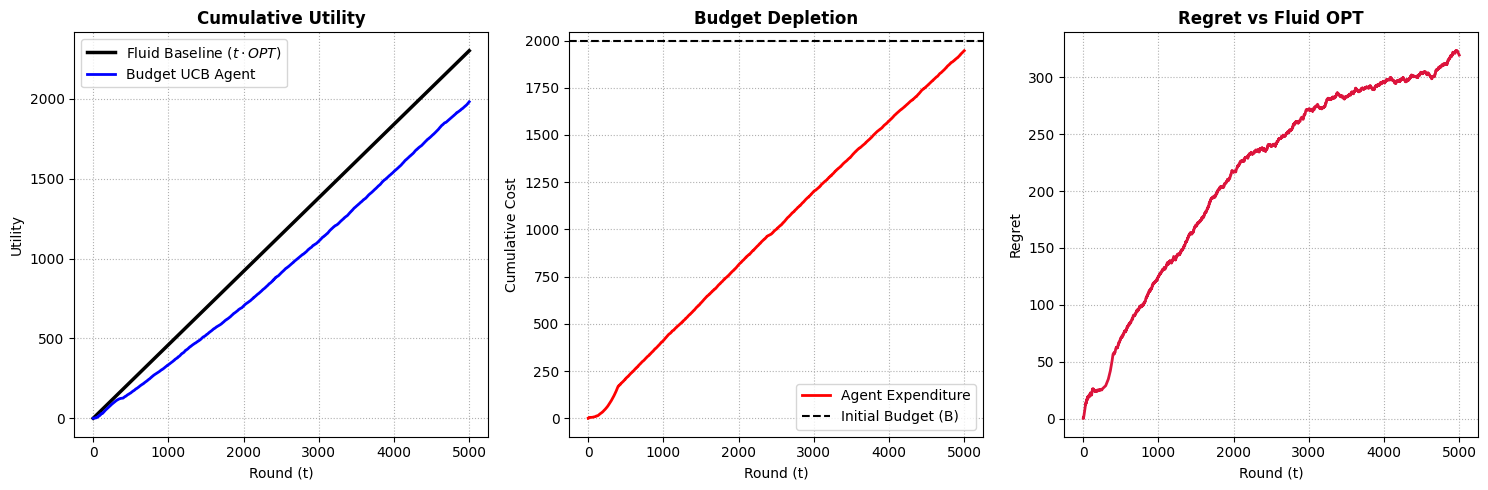

Rounds Played             : 5000 / 5000
Budget Remaining          : 53.80 / 2000.0
Optimal Expected (OPT)    : 0.4600 per round
Terminal Regret           : 319.36


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from scipy.optimize import linprog

# 1. System Configuration
T = 5000
K = 11
value = 1.0
B = 0.4*T # Binding budget constraint
rho = B / T
bid_space = np.linspace(0.0, 1.0, K)

alpha_param = 2
beta_param = 5

def beta_generator(size):
    return np.random.beta(alpha_param, beta_param, size=size)

# 2. Expected Fluid Baseline (OPT)
win_probabilities = beta.cdf(bid_space, a=alpha_param, b=beta_param)
expected_rewards = (value - bid_space) * win_probabilities
expected_costs = bid_space * win_probabilities

c_obj_base = -expected_rewards
A_ub_base = expected_costs.reshape(1, -1)
b_ub_base = np.array([rho])
A_eq_base = np.ones((1, K))
b_eq_base = np.array([1.0])
bounds_base = [(0, 1) for _ in range(K)]

res_base = linprog(c_obj_base, A_ub=A_ub_base, b_ub=b_ub_base, A_eq=A_eq_base, b_eq=b_eq_base, bounds=bounds_base, method='highs-ds')
gamma_opt = np.clip(res_base.x, 0, 1)
gamma_opt /= np.sum(gamma_opt)

OPT = np.sum(gamma_opt * expected_rewards)

# 3. Initialization
np.random.seed(42)
env = SingleCampaignEnvironment(value=value, T=T, distribution_func=beta_generator)
agent = BudgetConstrainedUCBAgent(value=value, bid_space=bid_space, B=B, T=T)

rewards_agent = np.zeros(T)
costs_agent = np.zeros(T)

# 4. Execution Loop (Strictly T iterations)
for t in range(T):
    arm_idx = agent.pull_arm()
    b_t = bid_space[arm_idx] # CRITICAL: Map index to float bid
    
    won, utility, cost = env.resolve_auction(b_t)
    
    agent.update(won, utility, cost) # CRITICAL: Adhere to signature
    
    rewards_agent[t] = utility
    costs_agent[t] = cost

# 5. Metrics & Regret
time_steps = np.arange(1, T + 1)
expected_cumulative_baseline = time_steps * OPT

cum_rewards_agent = np.cumsum(rewards_agent)
cum_costs_agent = np.cumsum(costs_agent)

regret = expected_cumulative_baseline - cum_rewards_agent

# 6. Plotting
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(time_steps, expected_cumulative_baseline, color='black', lw=2.5, label=r'Fluid Baseline ($t \cdot OPT$)')
plt.plot(time_steps, cum_rewards_agent, color='blue', lw=2, label='Budget UCB Agent')
plt.title('Cumulative Utility', fontweight='bold')
plt.xlabel('Round (t)')
plt.ylabel('Utility')
plt.grid(True, linestyle=':')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(time_steps, cum_costs_agent, color='red', lw=2, label='Agent Expenditure')
plt.axhline(y=B, color='black', linestyle='--', label='Initial Budget (B)')
plt.title('Budget Depletion', fontweight='bold')
plt.xlabel('Round (t)')
plt.ylabel('Cumulative Cost')
plt.grid(True, linestyle=':')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(time_steps, regret, color='crimson', lw=2)
plt.title('Regret vs Fluid OPT', fontweight='bold')
plt.xlabel('Round (t)')
plt.ylabel('Regret')
plt.grid(True, linestyle=':')

plt.tight_layout()
plt.show()

# 7. Terminal Outputs
print(f"Rounds Played             : {T} / {T}")
print(f"Budget Remaining          : {B - cum_costs_agent[-1]:.2f} / {B}")
print(f"Optimal Expected (OPT)    : {OPT:.4f} per round")
print(f"Terminal Regret           : {regret[-1]:.2f}")

### Several Trajectories : 

Executing Binding Constraint Simulation: N=10, T=5000, B=2000.0
Budgeted Fluid OPT: 0.4600 per round
Running simulation 0/10...
Running simulation 5/10...


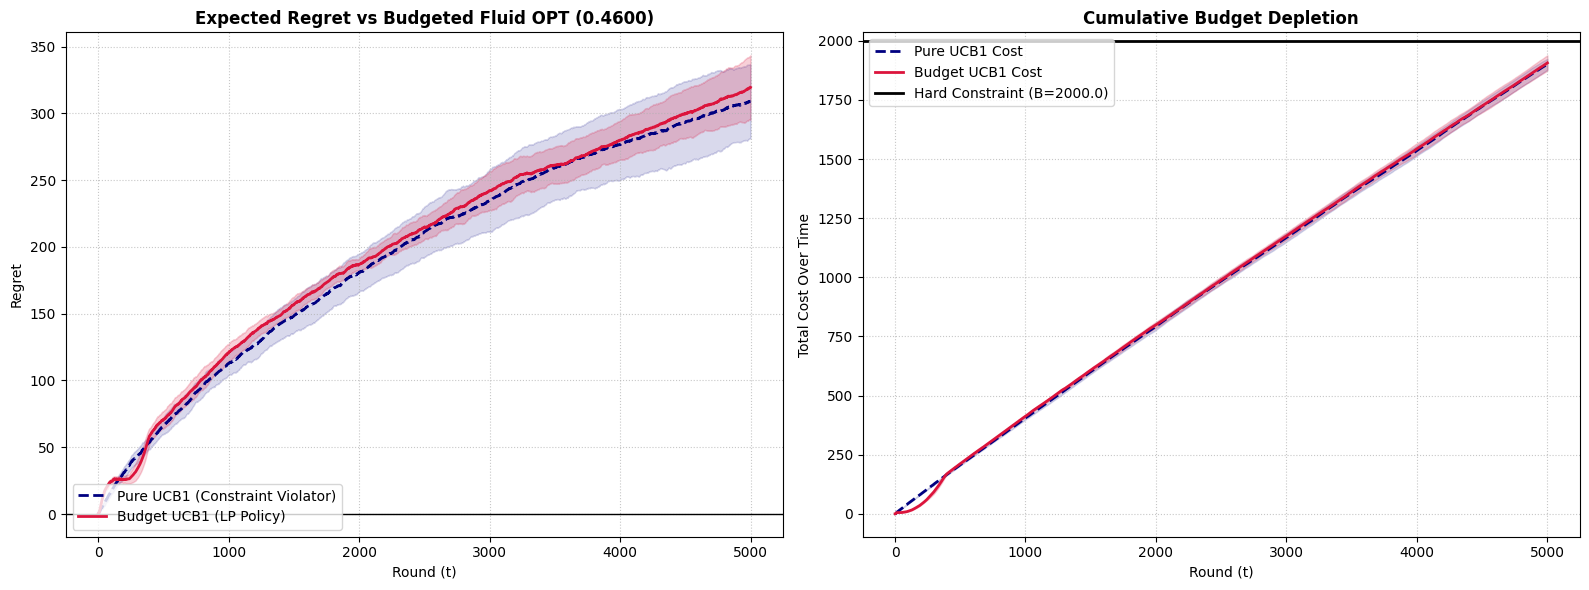


--- Final Analysis ---
Constraint Boundary: 2000.0
Budget UCB Final Cost: 1906.72
Pure UCB Final Cost:   1901.08 (Massive Overspend)


In [27]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from scipy.optimize import linprog

T = 5000
K = 11
N_SIMULATIONS = 10
value = 1.0

# Enforce a strict budget: T=5000, but only enough budget to spend 0.3 per round on average
B = 0.4*T
rho = B / T
bid_space = np.linspace(0.0, 1.0, K)

alpha_param = 2
beta_param = 5

def beta_generator(size):
    return np.random.beta(alpha_param, beta_param, size=size)

print(f"Executing Binding Constraint Simulation: N={N_SIMULATIONS}, T={T}, B={B}")

# 2. Expected Fluid Baseline (Budget-Constrained OPT)
win_probabilities = beta.cdf(bid_space, a=alpha_param, b=beta_param)
expected_rewards = (value - bid_space) * win_probabilities
expected_costs = bid_space * win_probabilities

c_obj_base = -expected_rewards
A_ub_base = expected_costs.reshape(1, -1)
b_ub_base = np.array([rho])
A_eq_base = np.ones((1, K))
b_eq_base = np.array([1.0])
bounds_base = [(0, 1) for _ in range(K)]

res_base = linprog(c_obj_base, A_ub=A_ub_base, b_ub=b_ub_base, A_eq=A_eq_base, b_eq=b_eq_base, bounds=bounds_base, method='highs-ds')
gamma_opt = np.clip(res_base.x, 0, 1)
gamma_opt /= np.sum(gamma_opt)

OPT_budget = np.sum(gamma_opt * expected_rewards)
print(f"Budgeted Fluid OPT: {OPT_budget:.4f} per round")

# 3. Allocation Matrices
regret_matrix_base = np.zeros((N_SIMULATIONS, T))
regret_matrix_budget = np.zeros((N_SIMULATIONS, T))

cost_matrix_base = np.zeros((N_SIMULATIONS, T))
cost_matrix_budget = np.zeros((N_SIMULATIONS, T))

time_steps = np.arange(1, T + 1)
expected_cumulative_baseline = time_steps * OPT_budget

# 4. Monte Carlo Loop
for sim in range(N_SIMULATIONS):
    if sim % 5 == 0:
        print(f"Running simulation {sim}/{N_SIMULATIONS}...")
        
    env_base = SingleCampaignEnvironment(value=value, T=T, distribution_func=beta_generator)
    env_budg = SingleCampaignEnvironment(value=value, T=T, distribution_func=beta_generator)
    
    ag_base = SingleCampaignUCB1Learner(value=value, bid_space=bid_space)
    ag_budg = BudgetConstrainedUCBAgent(value=value, bid_space=bid_space, B=B, T=T)
    
    traj_util_base = np.zeros(T)
    traj_cost_base = np.zeros(T)
    
    traj_util_budg = np.zeros(T)
    traj_cost_budg = np.zeros(T)
    
    for t in range(T):
        # Pure Agent (Ignorant of Budget)
        arm_b = ag_base.pull_arm()
        won_b, util_b, cost_b = env_base.resolve_auction(bid_space[arm_b])
        ag_base.update(won_b, util_b, cost_b)
        traj_util_base[t] = util_b
        traj_cost_base[t] = cost_b
        
        # Budget Agent (LP Constrained)
        arm_c = ag_budg.pull_arm()
        won_c, util_c, cost_c = env_budg.resolve_auction(bid_space[arm_c])
        ag_budg.update(won_c, util_c, cost_c)
        traj_util_budg[t] = util_c
        traj_cost_budg[t] = cost_c
        
    # Metrics Calculation
    cum_util_base = np.cumsum(traj_util_base)
    cum_util_budg = np.cumsum(traj_util_budg)
    
    regret_matrix_base[sim, :] = expected_cumulative_baseline - cum_util_base
    regret_matrix_budget[sim, :] = expected_cumulative_baseline - cum_util_budg
    
    cost_matrix_base[sim, :] = np.cumsum(traj_cost_base)
    cost_matrix_budget[sim, :] = np.cumsum(traj_cost_budg)

# 5. Statistical Aggregation
mean_regret_base = np.mean(regret_matrix_base, axis=0)
std_regret_base = np.std(regret_matrix_base, axis=0)

mean_regret_budget = np.mean(regret_matrix_budget, axis=0)
std_regret_budget = np.std(regret_matrix_budget, axis=0)

mean_cost_base = np.mean(cost_matrix_base, axis=0)
std_cost_base = np.std(cost_matrix_base, axis=0)

mean_cost_budget = np.mean(cost_matrix_budget, axis=0)
std_cost_budget = np.std(cost_matrix_budget, axis=0)

# 6. Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Regret Convergence
axes[0].plot(time_steps, mean_regret_base, color='navy', lw=2, linestyle='--', label='Pure UCB1 (Constraint Violator)')
axes[0].fill_between(time_steps, mean_regret_base - std_regret_base, mean_regret_base + std_regret_base, color='navy', alpha=0.15)

axes[0].plot(time_steps, mean_regret_budget, color='crimson', lw=2, label='Budget UCB1 (LP Policy)')
axes[0].fill_between(time_steps, mean_regret_budget - std_regret_budget, mean_regret_budget + std_regret_budget, color='crimson', alpha=0.2)

axes[0].axhline(y=0, color='black', lw=1, linestyle='-')
axes[0].set_title(f'Expected Regret vs Budgeted Fluid OPT ({OPT_budget:.4f})', fontweight='bold')
axes[0].set_xlabel('Round (t)')
axes[0].set_ylabel('Regret')
axes[0].grid(True, linestyle=':', alpha=0.7)
axes[0].legend(loc='lower left')

# Plot 2: Cumulative Budget Depletion
axes[1].plot(time_steps, mean_cost_base, color='navy', lw=2, linestyle='--', label='Pure UCB1 Cost')
axes[1].fill_between(time_steps, mean_cost_base - std_cost_base, mean_cost_base + std_cost_base, color='navy', alpha=0.15)

axes[1].plot(time_steps, mean_cost_budget, color='crimson', lw=2, label='Budget UCB1 Cost')
axes[1].fill_between(time_steps, mean_cost_budget - std_cost_budget, mean_cost_budget + std_cost_budget, color='crimson', alpha=0.2)

# The Hard Constraint Line
axes[1].axhline(y=B, color='black', lw=2, linestyle='-', label=f'Hard Constraint (B={B})')

axes[1].set_title('Cumulative Budget Depletion', fontweight='bold')
axes[1].set_xlabel('Round (t)')
axes[1].set_ylabel('Total Cost Over Time')
axes[1].grid(True, linestyle=':', alpha=0.7)
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

print("\n--- Final Analysis ---")
print(f"Constraint Boundary: {B}")
print(f"Budget UCB Final Cost: {mean_cost_budget[-1]:.2f}")
print(f"Pure UCB Final Cost:   {mean_cost_base[-1]:.2f} (Massive Overspend)")

Executing Binding Constraint Simulation: N=10, T=5000, B=1500.0
Budgeted Fluid OPT: 0.4573 per round
Running simulation 0/10...
Running simulation 5/10...


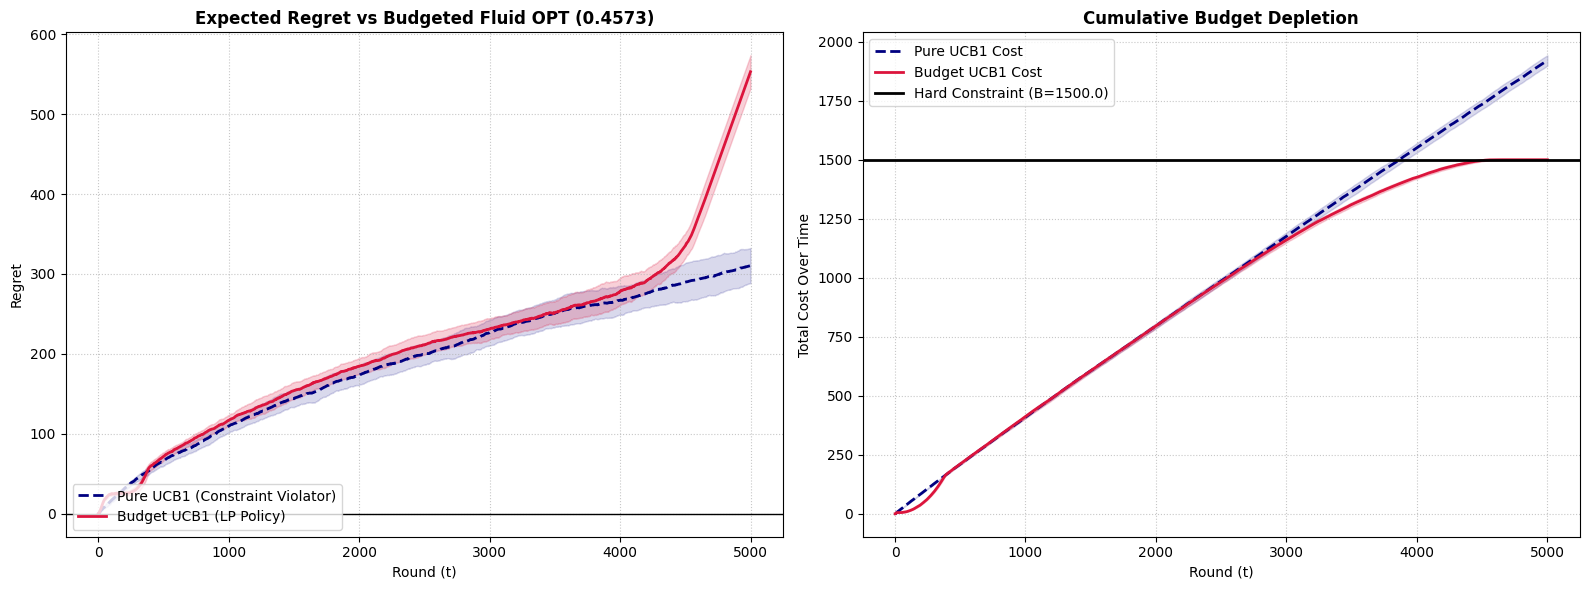


--- Final Analysis ---
Constraint Boundary: 1500.0
Budget UCB Final Cost: 1500.06
Pure UCB Final Cost:   1920.73 (Massive Overspend)


In [28]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from scipy.optimize import linprog

T = 5000
K = 11
N_SIMULATIONS = 10
value = 1.0

# Enforce a strict budget: T=5000, but only enough budget to spend 0.3 per round on average
B = 0.3*T
rho = B / T
bid_space = np.linspace(0.0, 1.0, K)

alpha_param = 2
beta_param = 5

def beta_generator(size):
    return np.random.beta(alpha_param, beta_param, size=size)

print(f"Executing Binding Constraint Simulation: N={N_SIMULATIONS}, T={T}, B={B}")

# 2. Expected Fluid Baseline (Budget-Constrained OPT)
win_probabilities = beta.cdf(bid_space, a=alpha_param, b=beta_param)
expected_rewards = (value - bid_space) * win_probabilities
expected_costs = bid_space * win_probabilities

c_obj_base = -expected_rewards
A_ub_base = expected_costs.reshape(1, -1)
b_ub_base = np.array([rho])
A_eq_base = np.ones((1, K))
b_eq_base = np.array([1.0])
bounds_base = [(0, 1) for _ in range(K)]

res_base = linprog(c_obj_base, A_ub=A_ub_base, b_ub=b_ub_base, A_eq=A_eq_base, b_eq=b_eq_base, bounds=bounds_base, method='highs-ds')
gamma_opt = np.clip(res_base.x, 0, 1)
gamma_opt /= np.sum(gamma_opt)

OPT_budget = np.sum(gamma_opt * expected_rewards)
print(f"Budgeted Fluid OPT: {OPT_budget:.4f} per round")

# 3. Allocation Matrices
regret_matrix_base = np.zeros((N_SIMULATIONS, T))
regret_matrix_budget = np.zeros((N_SIMULATIONS, T))

cost_matrix_base = np.zeros((N_SIMULATIONS, T))
cost_matrix_budget = np.zeros((N_SIMULATIONS, T))

time_steps = np.arange(1, T + 1)
expected_cumulative_baseline = time_steps * OPT_budget

# 4. Monte Carlo Loop
for sim in range(N_SIMULATIONS):
    if sim % 5 == 0:
        print(f"Running simulation {sim}/{N_SIMULATIONS}...")
        
    env_base = SingleCampaignEnvironment(value=value, T=T, distribution_func=beta_generator)
    env_budg = SingleCampaignEnvironment(value=value, T=T, distribution_func=beta_generator)
    
    ag_base = SingleCampaignUCB1Learner(value=value, bid_space=bid_space)
    ag_budg = BudgetConstrainedUCBAgent(value=value, bid_space=bid_space, B=B, T=T)
    
    traj_util_base = np.zeros(T)
    traj_cost_base = np.zeros(T)
    
    traj_util_budg = np.zeros(T)
    traj_cost_budg = np.zeros(T)
    
    for t in range(T):
        # Pure Agent (Ignorant of Budget)
        arm_b = ag_base.pull_arm()
        won_b, util_b, cost_b = env_base.resolve_auction(bid_space[arm_b])
        ag_base.update(won_b, util_b, cost_b)
        traj_util_base[t] = util_b
        traj_cost_base[t] = cost_b
        
        # Budget Agent (LP Constrained)
        arm_c = ag_budg.pull_arm()
        won_c, util_c, cost_c = env_budg.resolve_auction(bid_space[arm_c])
        ag_budg.update(won_c, util_c, cost_c)
        traj_util_budg[t] = util_c
        traj_cost_budg[t] = cost_c
        
    # Metrics Calculation
    cum_util_base = np.cumsum(traj_util_base)
    cum_util_budg = np.cumsum(traj_util_budg)
    
    regret_matrix_base[sim, :] = expected_cumulative_baseline - cum_util_base
    regret_matrix_budget[sim, :] = expected_cumulative_baseline - cum_util_budg
    
    cost_matrix_base[sim, :] = np.cumsum(traj_cost_base)
    cost_matrix_budget[sim, :] = np.cumsum(traj_cost_budg)

# 5. Statistical Aggregation
mean_regret_base = np.mean(regret_matrix_base, axis=0)
std_regret_base = np.std(regret_matrix_base, axis=0)

mean_regret_budget = np.mean(regret_matrix_budget, axis=0)
std_regret_budget = np.std(regret_matrix_budget, axis=0)

mean_cost_base = np.mean(cost_matrix_base, axis=0)
std_cost_base = np.std(cost_matrix_base, axis=0)

mean_cost_budget = np.mean(cost_matrix_budget, axis=0)
std_cost_budget = np.std(cost_matrix_budget, axis=0)

# 6. Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Regret Convergence
axes[0].plot(time_steps, mean_regret_base, color='navy', lw=2, linestyle='--', label='Pure UCB1 (Constraint Violator)')
axes[0].fill_between(time_steps, mean_regret_base - std_regret_base, mean_regret_base + std_regret_base, color='navy', alpha=0.15)

axes[0].plot(time_steps, mean_regret_budget, color='crimson', lw=2, label='Budget UCB1 (LP Policy)')
axes[0].fill_between(time_steps, mean_regret_budget - std_regret_budget, mean_regret_budget + std_regret_budget, color='crimson', alpha=0.2)

axes[0].axhline(y=0, color='black', lw=1, linestyle='-')
axes[0].set_title(f'Expected Regret vs Budgeted Fluid OPT ({OPT_budget:.4f})', fontweight='bold')
axes[0].set_xlabel('Round (t)')
axes[0].set_ylabel('Regret')
axes[0].grid(True, linestyle=':', alpha=0.7)
axes[0].legend(loc='lower left')

# Plot 2: Cumulative Budget Depletion
axes[1].plot(time_steps, mean_cost_base, color='navy', lw=2, linestyle='--', label='Pure UCB1 Cost')
axes[1].fill_between(time_steps, mean_cost_base - std_cost_base, mean_cost_base + std_cost_base, color='navy', alpha=0.15)

axes[1].plot(time_steps, mean_cost_budget, color='crimson', lw=2, label='Budget UCB1 Cost')
axes[1].fill_between(time_steps, mean_cost_budget - std_cost_budget, mean_cost_budget + std_cost_budget, color='crimson', alpha=0.2)

# The Hard Constraint Line
axes[1].axhline(y=B, color='black', lw=2, linestyle='-', label=f'Hard Constraint (B={B})')

axes[1].set_title('Cumulative Budget Depletion', fontweight='bold')
axes[1].set_xlabel('Round (t)')
axes[1].set_ylabel('Total Cost Over Time')
axes[1].grid(True, linestyle=':', alpha=0.7)
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

print("\n--- Final Analysis ---")
print(f"Constraint Boundary: {B}")
print(f"Budget UCB Final Cost: {mean_cost_budget[-1]:.2f}")
print(f"Pure UCB Final Cost:   {mean_cost_base[-1]:.2f} (Massive Overspend)")

Executing 3-Way Comparison: N=2, T=50000, B=15000.0
Running simulation 0/2...


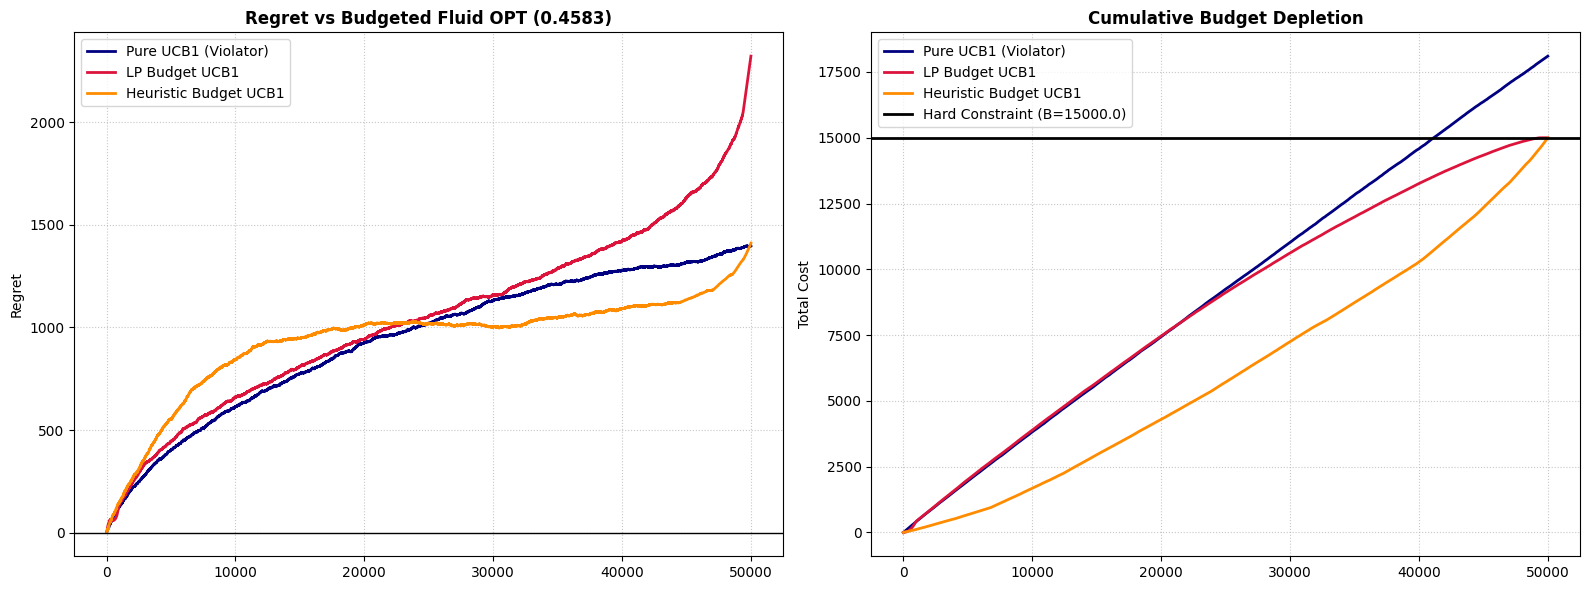


--- Final Analysis ---
Pure UCB1 (Violator) Final Cost: 18100.53
LP Budget UCB1 Final Cost: 15000.00
Heuristic Budget UCB1 Final Cost: 15000.00


In [25]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from scipy.optimize import linprog

# 1. Configuration (Binding Budget)
T = 50000
K = 21
N_SIMULATIONS = 2
value = 1.0

B = 0.3*T  
rho = B / T
bid_space = np.linspace(0.0, 1.0, K)

alpha_param = 2
beta_param = 5

def beta_generator(size):
    return np.random.beta(alpha_param, beta_param, size=size)

# 2. Fluid OPT
win_probs = beta.cdf(bid_space, a=alpha_param, b=beta_param)
exp_rewards = (value - bid_space) * win_probs
exp_costs = bid_space * win_probs

res_base = linprog(-exp_rewards, A_ub=exp_costs.reshape(1, -1), b_ub=np.array([rho]), 
                   A_eq=np.ones((1, K)), b_eq=np.array([1.0]), bounds=[(0, 1) for _ in range(K)], method='highs-ds')
gamma_opt = np.clip(res_base.x, 0, 1)
gamma_opt /= np.sum(gamma_opt)
OPT_budget = np.sum(gamma_opt * exp_rewards)

# 3. Data Matrices
time_steps = np.arange(1, T + 1)
expected_cumulative_baseline = time_steps * OPT_budget

metrics = {
    'base': {'regret': np.zeros((N_SIMULATIONS, T)), 'cost': np.zeros((N_SIMULATIONS, T))},
    'lp': {'regret': np.zeros((N_SIMULATIONS, T)), 'cost': np.zeros((N_SIMULATIONS, T))},
    'heur': {'regret': np.zeros((N_SIMULATIONS, T)), 'cost': np.zeros((N_SIMULATIONS, T))}
}

# 4. Execution Loop
print(f"Executing 3-Way Comparison: N={N_SIMULATIONS}, T={T}, B={B}")

for sim in range(N_SIMULATIONS):
    if sim % 5 == 0: print(f"Running simulation {sim}/{N_SIMULATIONS}...")
        
    envs = [SingleCampaignEnvironment(value, T, beta_generator) for _ in range(3)]
    
    agents = {
        'base': SingleCampaignUCB1Learner(value, bid_space),
        'lp': BudgetConstrainedUCBAgent(value, bid_space, B, T),
        'heur': HeuristicBudgetUCBAgent(value, bid_space, B, T)
    }
    
    trajectories = {k: {'util': np.zeros(T), 'cost': np.zeros(T)} for k in agents}
    
    for t in range(T):
        for key in agents:
            arm = agents[key].pull_arm()
            won, util, cost = envs[list(agents.keys()).index(key)].resolve_auction(bid_space[arm])
            agents[key].update(won, util, cost)
            
            trajectories[key]['util'][t] = util
            trajectories[key]['cost'][t] = cost
            
    for key in agents:
        metrics[key]['regret'][sim, :] = expected_cumulative_baseline - np.cumsum(trajectories[key]['util'])
        metrics[key]['cost'][sim, :] = np.cumsum(trajectories[key]['cost'])

# 5. Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = {'base': 'navy', 'lp': 'crimson', 'heur': 'darkorange'}
labels = {'base': 'Pure UCB1 (Violator)', 'lp': 'LP Budget UCB1', 'heur': 'Heuristic Budget UCB1'}

for key in metrics:
    mean_regret = np.mean(metrics[key]['regret'], axis=0)
    axes[0].plot(time_steps, mean_regret, color=colors[key], lw=2, label=labels[key])
    
    mean_cost = np.mean(metrics[key]['cost'], axis=0)
    axes[1].plot(time_steps, mean_cost, color=colors[key], lw=2, label=labels[key])

axes[0].axhline(0, color='black', lw=1)
axes[0].set_title(f'Regret vs Budgeted Fluid OPT ({OPT_budget:.4f})', fontweight='bold')
axes[0].set_ylabel('Regret')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.7)

axes[1].axhline(B, color='black', lw=2, linestyle='-', label=f'Hard Constraint (B={B})')
axes[1].set_title('Cumulative Budget Depletion', fontweight='bold')
axes[1].set_ylabel('Total Cost')
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

print("\n--- Final Analysis ---")
for key in metrics:
    print(f"{labels[key]} Final Cost: {np.mean(metrics[key]['cost'], axis=0)[-1]:.2f}")

Executing 3-Way Comparison (B=1500.0): 100%|████████████████████████████████████████████| 3/3 [06:48<00:00, 136.09s/it]


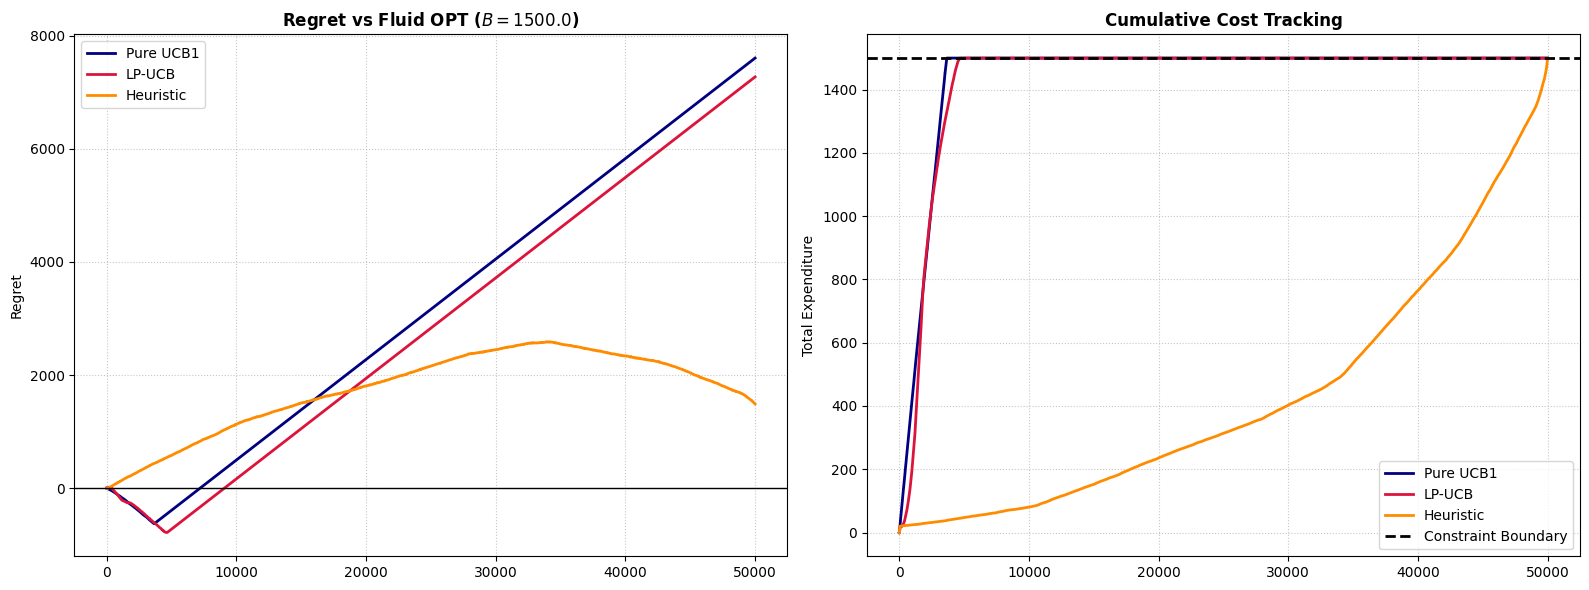

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from scipy.optimize import linprog
from tqdm.auto import tqdm

# 1. Configuration (Reviewer Specs)
T = 50000
K = 41 # Expanded grid
N_SIMULATIONS = 3
value = 1.0

B = 1500.0  # Test 1. Change to 800.0 for Test 2.
rho = B / T
bid_space = np.linspace(0.0, 1.0, K)

alpha_param = 2
beta_param = 5

def beta_generator(size):
    return np.random.beta(alpha_param, beta_param, size=size)

# 2. Fluid OPT
win_probs = beta.cdf(bid_space, a=alpha_param, b=beta_param)
exp_rewards = (value - bid_space) * win_probs
exp_costs = bid_space * win_probs

res_base = linprog(-exp_rewards, A_ub=exp_costs.reshape(1, -1), b_ub=np.array([rho]), 
                   A_eq=np.ones((1, K)), b_eq=np.array([1.0]), bounds=[(0, 1) for _ in range(K)], method='highs-ds')
gamma_opt = np.clip(res_base.x, 0, 1)
gamma_opt /= np.sum(gamma_opt)
OPT_budget = np.sum(gamma_opt * exp_rewards)

# 3. Data Matrices
time_steps = np.arange(1, T + 1)
expected_cumulative_baseline = time_steps * OPT_budget

metrics = {
    'base': {'regret': np.zeros((N_SIMULATIONS, T)), 'cost': np.zeros((N_SIMULATIONS, T))},
    'lp': {'regret': np.zeros((N_SIMULATIONS, T)), 'cost': np.zeros((N_SIMULATIONS, T))},
    'heur': {'regret': np.zeros((N_SIMULATIONS, T)), 'cost': np.zeros((N_SIMULATIONS, T))}
}

# 4. Monte Carlo Execution Loop
for sim in tqdm(range(N_SIMULATIONS), desc=f"Executing 3-Way Comparison (B={B})"):
        
    envs = [SingleCampaignEnvironment(value, T, beta_generator) for _ in range(3)]
    
    agents = {
        'base': SingleCampaignUCB1Learner(value, bid_space),
        'lp': BudgetConstrainedUCBAgent(value, bid_space, B, T),
        'heur': HeuristicBudgetUCBAgent(value, bid_space, B, T)
    }
    
    trajectories = {k: {'util': np.zeros(T), 'cost': np.zeros(T)} for k in agents}
    exchange_budgets = {'base': B, 'lp': B, 'heur': B}
    
    for t in range(T):
        for key in agents:
            arm = agents[key].pull_arm()
            
            # Strict Environmental Execution
            if exchange_budgets[key] < 1.0:
                won, util, cost = False, 0.0, 0.0
            else:
                won, util, cost = envs[list(agents.keys()).index(key)].resolve_auction(bid_space[arm])
                exchange_budgets[key] -= cost
                
            agents[key].update(won, util, cost)
            
            trajectories[key]['util'][t] = util
            trajectories[key]['cost'][t] = cost
            
    for key in agents:
        metrics[key]['regret'][sim, :] = expected_cumulative_baseline - np.cumsum(trajectories[key]['util'])
        metrics[key]['cost'][sim, :] = np.cumsum(trajectories[key]['cost'])

# 5. Visualization Extraction
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = {'base': 'navy', 'lp': 'crimson', 'heur': 'darkorange'}
labels = {'base': 'Pure UCB1', 'lp': 'LP-UCB', 'heur': 'Heuristic'}

for key in metrics:
    mean_regret = np.mean(metrics[key]['regret'], axis=0)
    axes[0].plot(time_steps, mean_regret, color=colors[key], lw=2, label=labels[key])
    
    mean_cost = np.mean(metrics[key]['cost'], axis=0)
    axes[1].plot(time_steps, mean_cost, color=colors[key], lw=2, label=labels[key])

axes[0].axhline(0, color='black', lw=1)
axes[0].set_title(f'Regret vs Fluid OPT ($B={B}$)', fontweight='bold')
axes[0].set_ylabel('Regret')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.7)

axes[1].axhline(B, color='black', lw=2, linestyle='--', label='Constraint Boundary')
axes[1].set_title('Cumulative Cost Tracking', fontweight='bold')
axes[1].set_ylabel('Total Expenditure')
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

## Comments 

Now we can also implement the pacing strategy. 

# Pacing Strategy 

---
## Part 3: Algorithm 2 — Budget-Constrained UCB1

We now extend UCB1 to respect a **total budget** $B$ (maximum total spend).

**Key idea**: the agent must not only maximise reward, but also *control its spending rate*. We use a **pacing** approach:

- At round $t$, the agent has spent $S_t$ so far and has $B - S_t$ remaining budget.
- It has $T - t$ rounds left.
- It should not bid on arms whose **expected cost** would likely exhaust the budget too fast.
- We filter out arms $k$ whose expected cost $\hat{c}_k$ exceeds the remaining budget per round:
  $$\text{remaining budget per round} = \frac{B - S_t}{T - t}$$
- Among affordable arms, we select the one with the **highest UCB index**.
- If the remaining budget is exhausted ($B - S_t \leq 0$), the agent **stops bidding** (bids arm 0, which has bid 0).

### Remarks

1. **UCB1 without budget** achieves lower regret (it can always play the optimal arm) but **ignores total spending** — cumulative spend grows linearly and may exceed any fixed budget.

2. **Budget-constrained UCB1** enforces the budget via pacing: it filters out arms that are too expensive given the remaining budget. As a result:
   - Total spend stays **below $B$**.
   - Regret is higher: the agent must sometimes forgo the optimal bid to stay within budget.
   - The sub-linear shape is preserved whenever the budget is sufficient for a good-enough arm to be played most of the time.

3. The regret measured here is against the **unconstrained clairvoyant** (always plays the best arm). A tighter benchmark would be the best arm affordable within budget.